In [109]:
import pandas as pd
from PetrizzeTheme import petrizze_template
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

import ipywidgets as widgets

petrizze_template()

moniker = 'Gaussian'

df = pd.read_parquet(f"Out\\Data-True {moniker}.parquet")

df["True_Exciton_Energy_Diff"] = df["True_exciton_T_energy"] - df["True_exciton_X_energy"]
a = df["Fit_exciton_1_energy"]
b = df["Fit_exciton_0_energy"]
df["Fit_Exciton_Energy_Diff"] = np.minimum(a, b) - np.maximum(a, b)
df["True_Fit_Exciton_Diff"] = df["Fit_Exciton_Energy_Diff"] - df["True_Exciton_Energy_Diff"]
true = df["True_Exciton_Energy_Diff"]
fit = df["Fit_Exciton_Energy_Diff"]
df["True_Fit_Exciton_Diff_%"] = (true - fit) / true * 100

columns = df.columns
for column in columns:
    print(column)

def label(label):
    label = label.replace('_', ' ')
    label = label.replace('CHI2', 'χ2')
    label = label.replace('RED', 'Reduced')
    label = label.replace('True Fit Exciton Diff %', '% Error')
    return label


def quad_plot(parameter_x, parameter_y, xlabel=None, ylabel=None, x_range=None, y_range=None, showexpected=False):
    if not xlabel:
        xlabel = label(parameter_x)
    if not ylabel:
        ylabel = label(parameter_y)

    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(19.2, 10.8), sharex=True, sharey=True)
    fig.subplots_adjust(wspace=0, hspace=0)
    ax = ax.flatten()
    for j, (noise_key, noise_data) in enumerate(df.groupby("NOISE_STD_VALUE")):
        for i, (lineshape_key, lineshape_data) in enumerate(noise_data.groupby("LINESHAPE_KEY")):

            x = lineshape_data[parameter_x]
            y = lineshape_data[parameter_y]

            ax[j].plot(x, y, label=lineshape_key, marker='o', linestyle='None')
        
        if showexpected:
            ax[j].plot(x, x, '--', label='True', color='#F4F5F7')

        ax[j].annotate(f'{noise_key} noise std', xy=(0.8, 0.95), xycoords='axes fraction')

        if x_range:
            ax[j].set_xlim(x_range[0], x_range[1])
        if y_range:
            ax[j].set_ylim(y_range[0], y_range[1])
        # ax[j].set_title(f'{noise_key} noise std')
        
    ax[0].set_ylabel(f'{ylabel}')
    ax[2].set_ylabel(f'{ylabel}')
    ax[2].set_xlabel(f'{xlabel}')
    ax[3].set_xlabel(f'{xlabel}')

    ax[0].yaxis.set_major_locator(MaxNLocator(prune='lower'))
    ax[1].yaxis.set_major_locator(MaxNLocator(prune='lower'))
    ax[2].yaxis.set_major_locator(MaxNLocator(prune='upper'))
    ax[3].yaxis.set_major_locator(MaxNLocator(prune='upper'))
    
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc='center left',
        bbox_to_anchor=(0.00, 0.5)
    )
    fig.subplots_adjust(right=0.8)


    plt.savefig(f'Out\\Plots\\{moniker}\\Quad Plot {parameter_y} vs {parameter_x}.png', bbox_inches='tight')
    # plt.show()


CONVERGED
SEED
TIME
True_exciton_X_energy
True_exciton_X_amplitude
True_exciton_X_lineshape
True_exciton_X_linewidth
True_exciton_X_linewidth_g
True_exciton_X_linewidth_l
True_exciton_X_weight
True_exciton_T_energy
True_exciton_T_amplitude
True_exciton_T_lineshape
True_exciton_T_linewidth
True_exciton_T_linewidth_g
True_exciton_T_linewidth_l
True_exciton_T_weight
Guess_exciton_0_energy
Guess_exciton_0_amplitude
Guess_exciton_0_lineshape
Guess_exciton_0_linewidth
Guess_exciton_0_linewidth_g
Guess_exciton_0_linewidth_l
Guess_exciton_0_weight
Guess_exciton_1_energy
Guess_exciton_1_amplitude
Guess_exciton_1_lineshape
Guess_exciton_1_linewidth
Guess_exciton_1_linewidth_g
Guess_exciton_1_linewidth_l
Guess_exciton_1_weight
Fit_exciton_0_energy
Fit_exciton_0_amplitude
Fit_exciton_0_lineshape
Fit_exciton_0_linewidth
Fit_exciton_0_linewidth_g
Fit_exciton_0_linewidth_l
Fit_exciton_0_weight
Fit_exciton_1_energy
Fit_exciton_1_amplitude
Fit_exciton_1_lineshape
Fit_exciton_1_linewidth
Fit_exciton_1_l

# Fit Energy Difference vs True Energy Difference

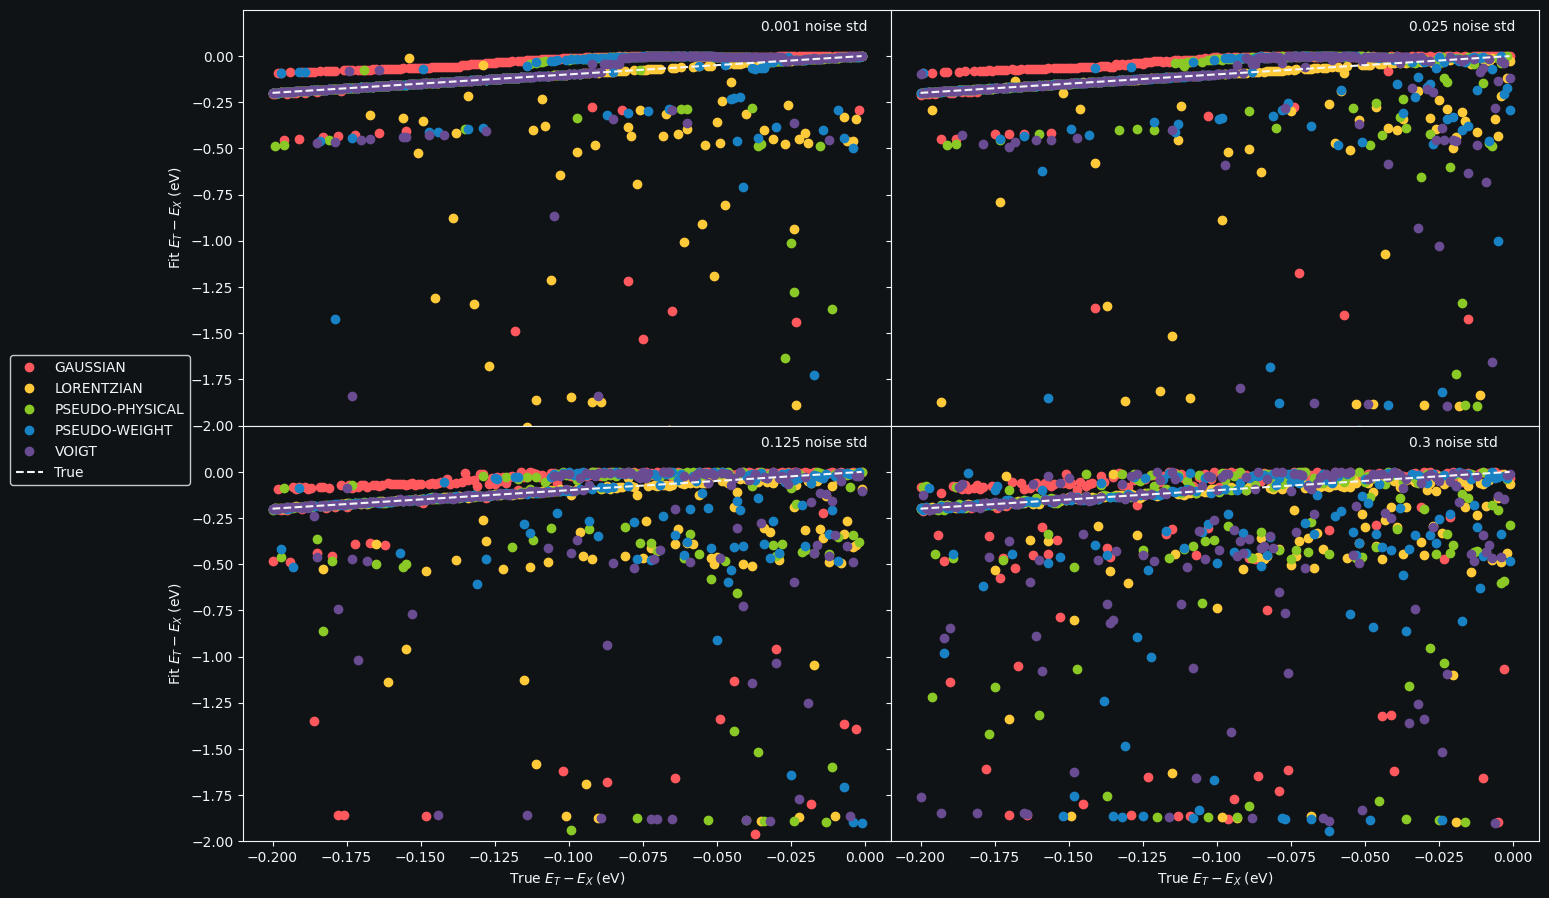

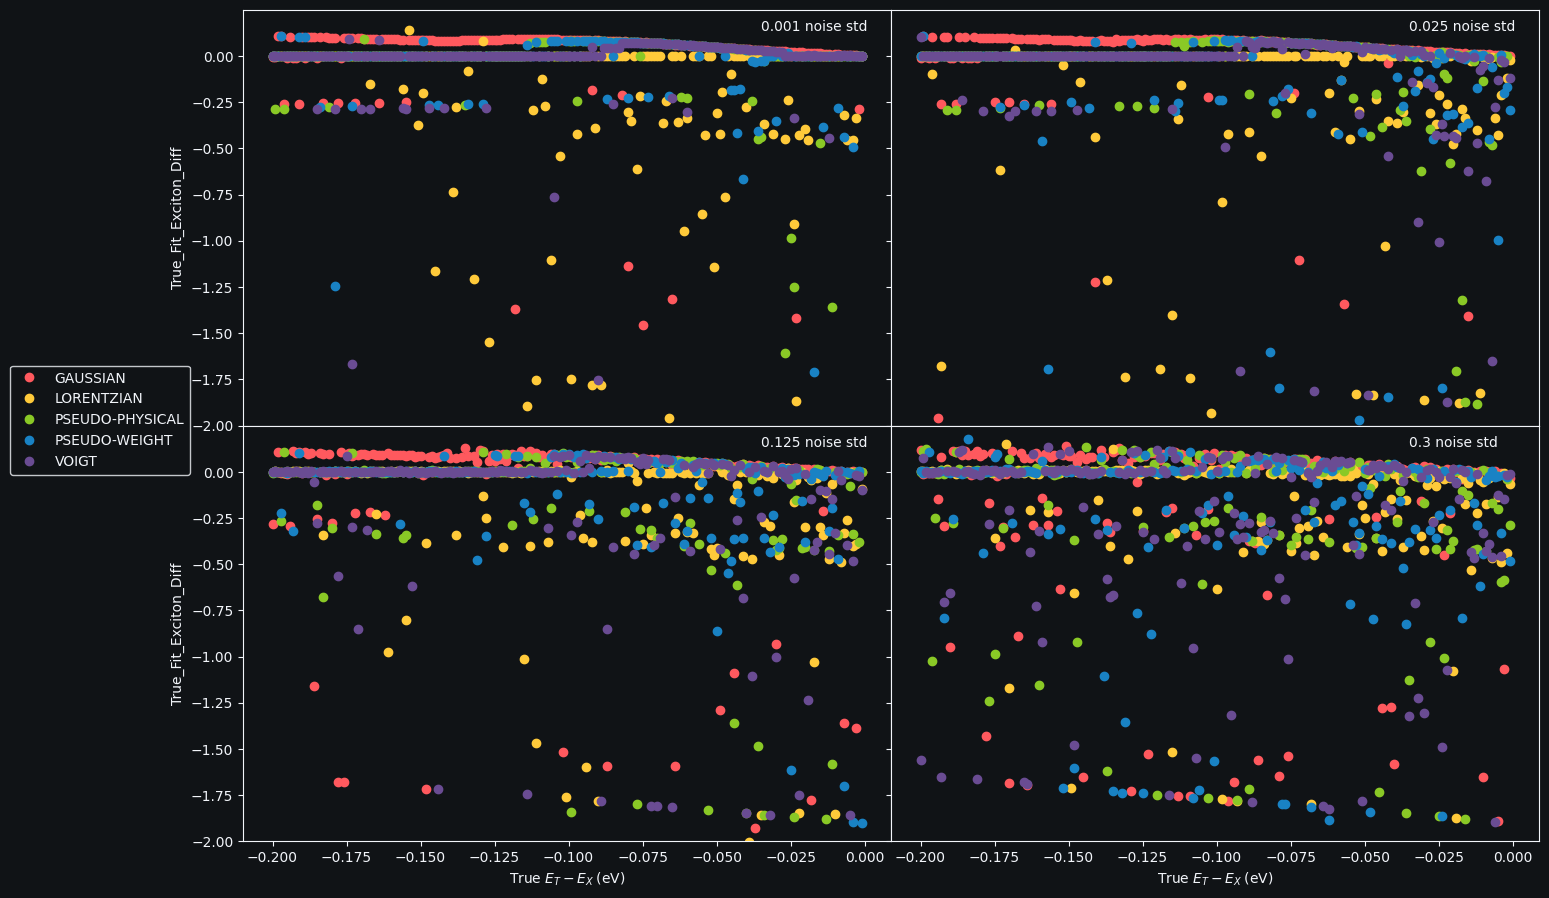

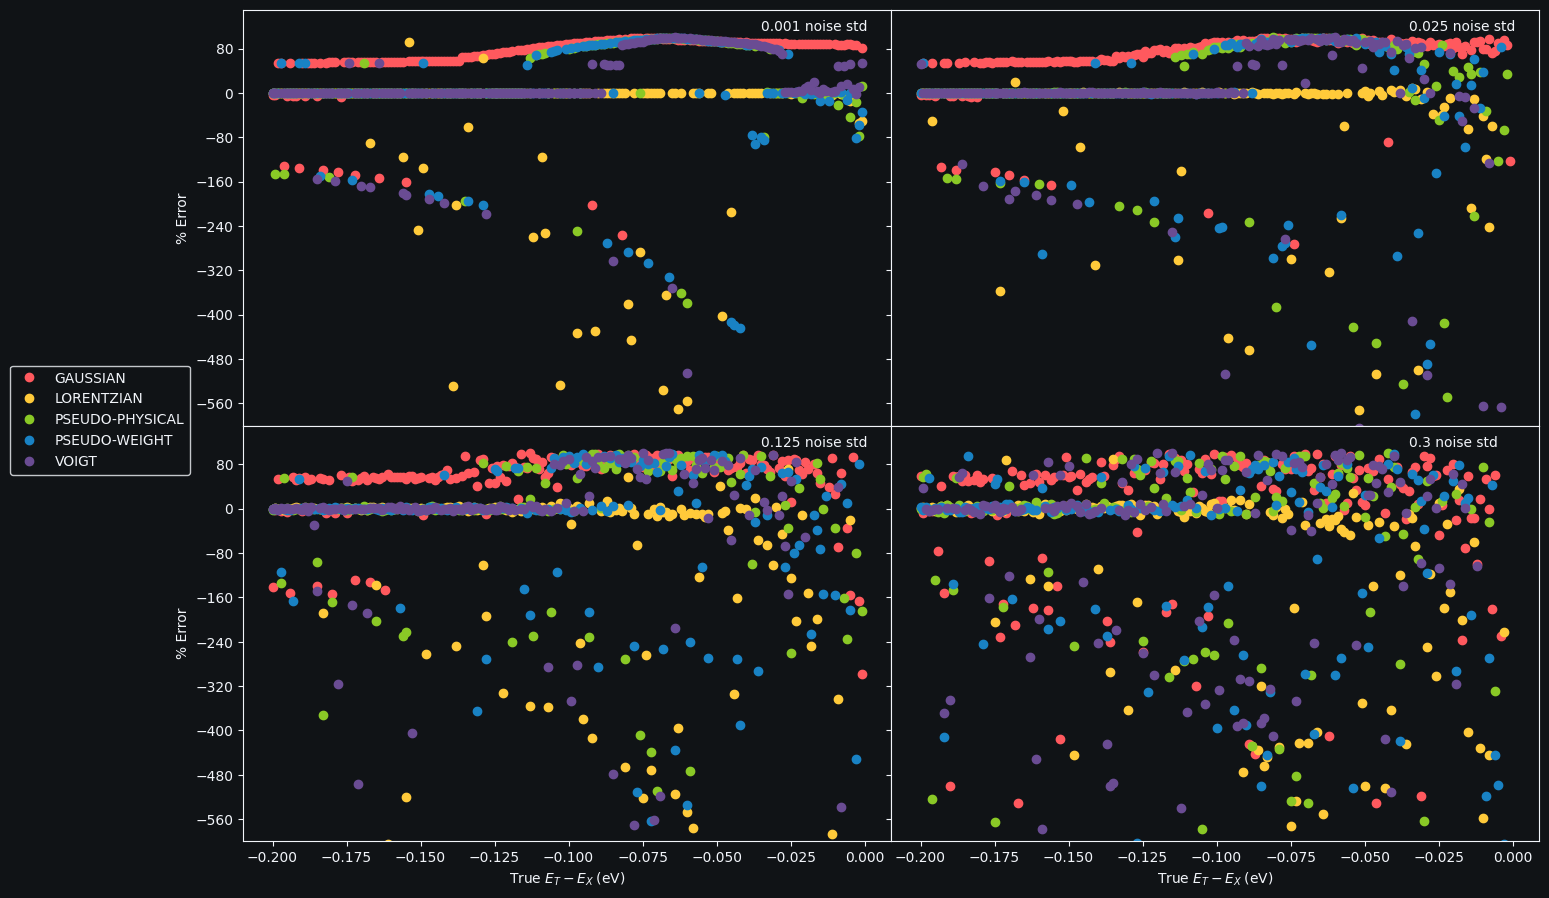

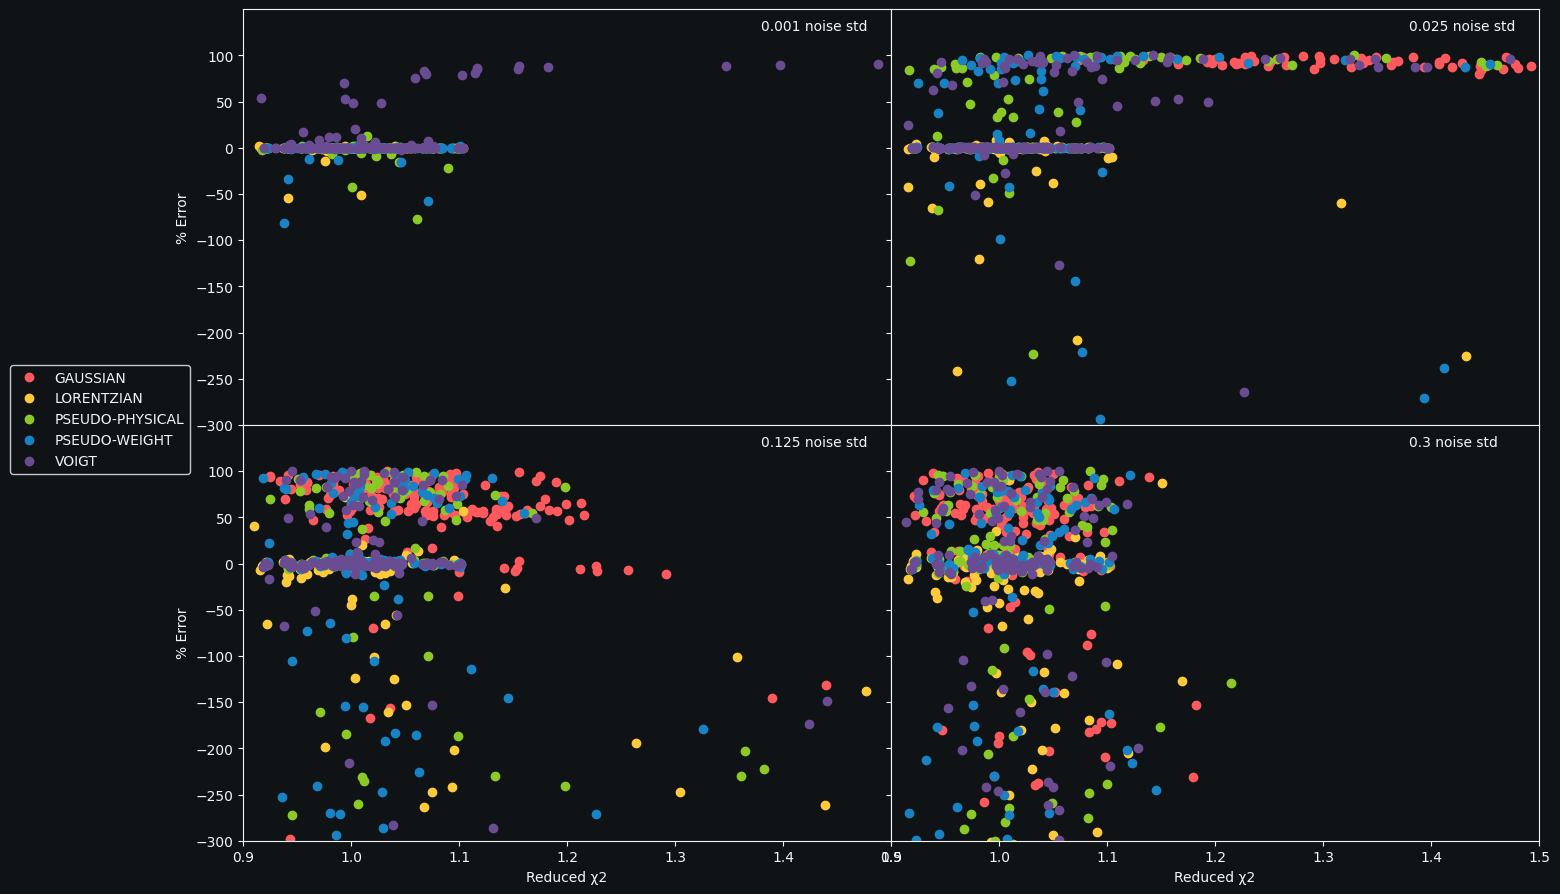

In [110]:
xlabel = r'$\mathrm{True}\; E_T - E_X\;(\mathrm{eV})$'
ylabel = r'$\mathrm{Fit}\; E_T - E_X\;(\mathrm{eV})$'
quad_plot("True_Exciton_Energy_Diff", "Fit_Exciton_Energy_Diff", xlabel, ylabel, y_range=[-2, 0.25], showexpected=True)

xlabel = r'$\mathrm{True}\; E_T - E_X\;(\mathrm{eV})$'
ylabel = r'True_Fit_Exciton_Diff'
quad_plot("True_Exciton_Energy_Diff", "True_Fit_Exciton_Diff", xlabel, ylabel, y_range=[-2, 0.25])

xlabel = r'$\mathrm{True}\; E_T - E_X\;(\mathrm{eV})$'
quad_plot("True_Exciton_Energy_Diff", "True_Fit_Exciton_Diff_%", xlabel, y_range=[-600, 150])

quad_plot("RED_CHI2", "True_Fit_Exciton_Diff_%",  y_range=[-300, 150], x_range=[0.9, 1.5])



# Parameter vs Histograms

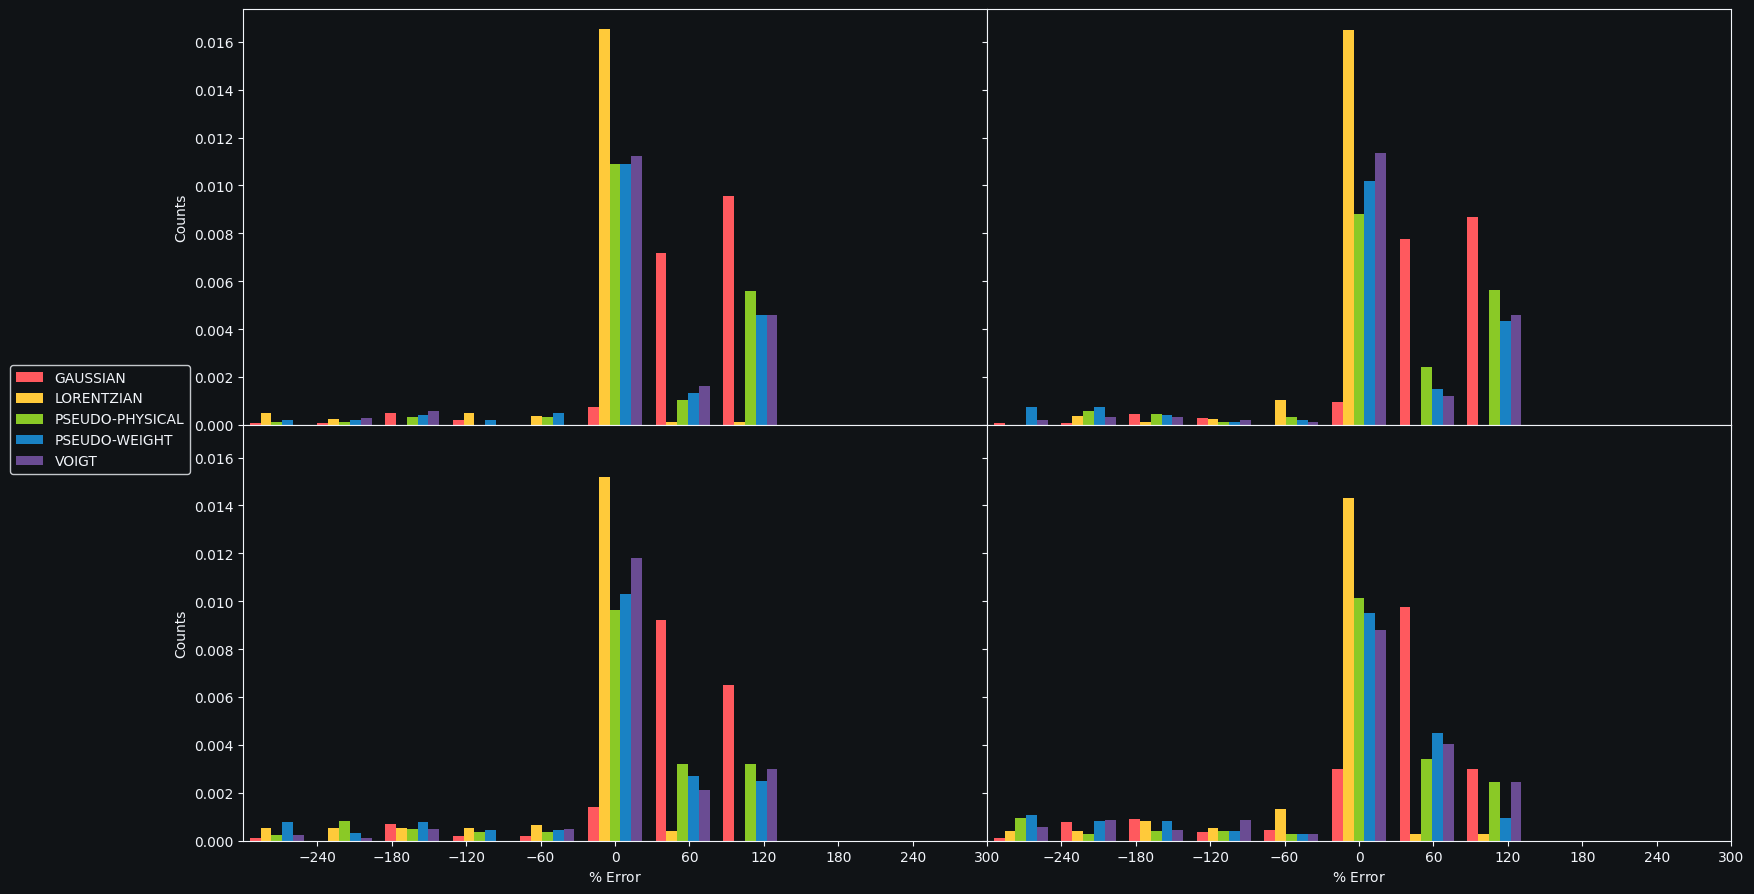

c:\Users\alexa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


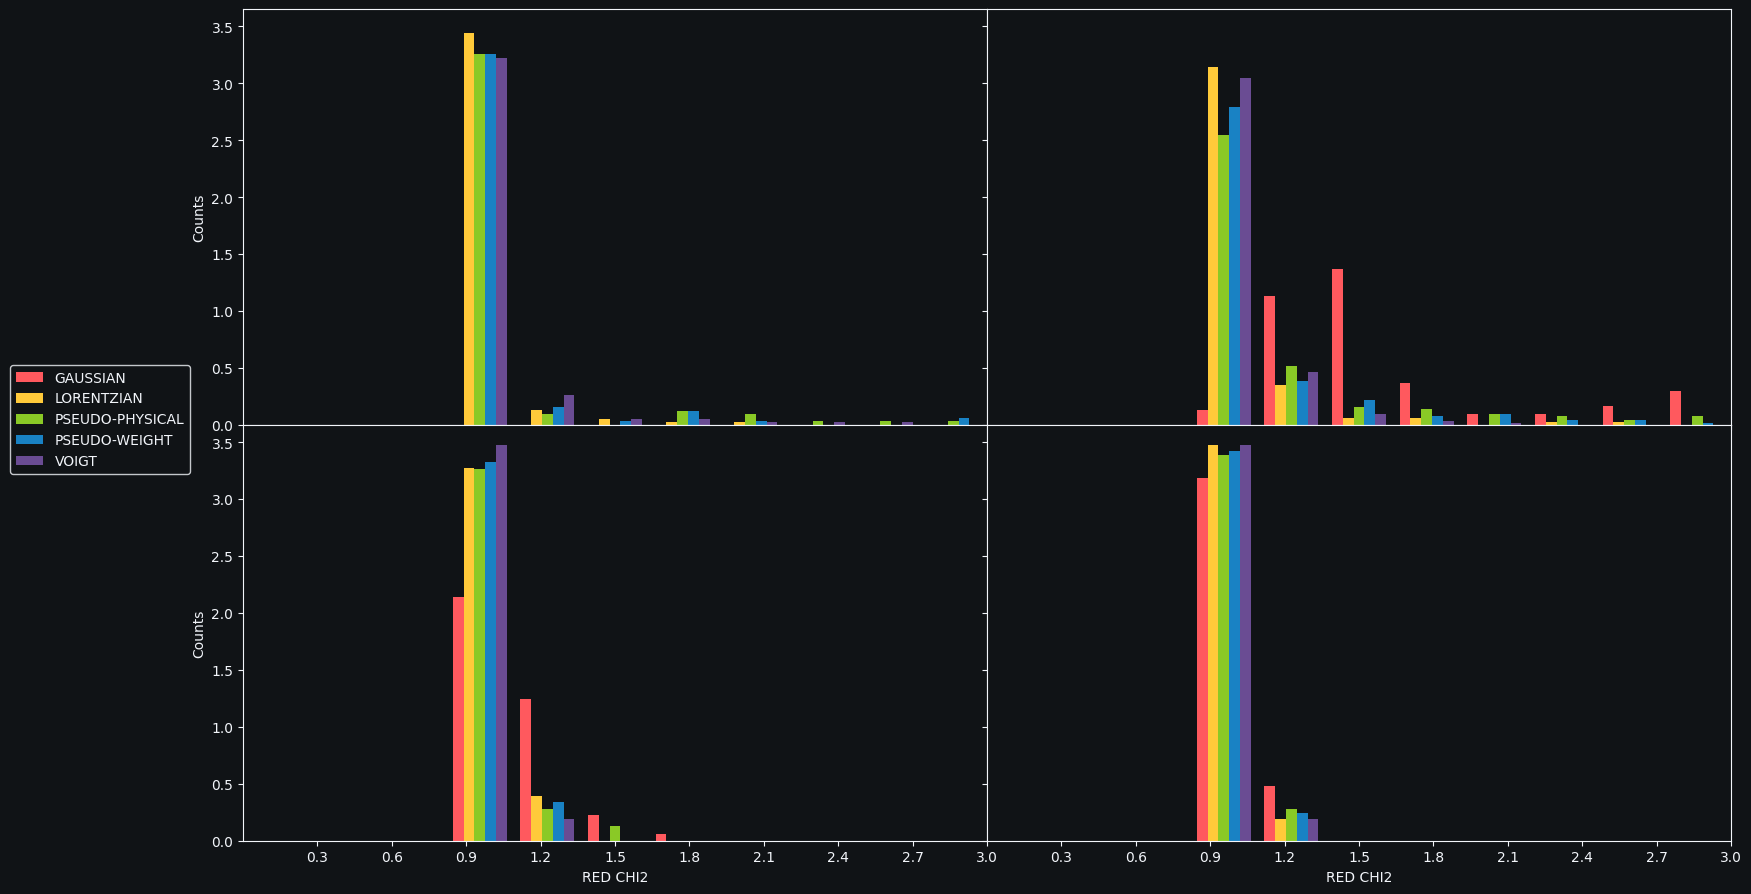

In [55]:

def filter_2sigma(x):
    mu = np.mean(x)
    sigma = np.std(x)
    return x[(x >= mu - 2 * sigma) & (x <= mu + 2 * sigma)]

def quad_histogram(parameter, xlabel=None, x_range=None, n_bins=10, pdf=True):
    if not xlabel:
        xlabel = label(parameter)

    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(19.2, 10.8), sharex=True, sharey=True)
    ax = ax.flatten()
    fig.subplots_adjust(wspace=0, hspace=0)
    for j, (noise_key, noise_data) in enumerate(df.groupby("NOISE_STD_VALUE")):
    
        grouped = list(noise_data.groupby("LINESHAPE_KEY"))
        
        # Filter each dataset
        filtered_data = [filter_2sigma(g[1][parameter]) for g in grouped]
        labels = [g[0] for g in grouped]

        # Combine filtered data to define consistent bins
        all_filtered = np.concatenate(filtered_data)

        bins = np.linspace(x_range[0], x_range[1], n_bins + 1)


        ax[j].hist(
            filtered_data,
            bins=bins,
            label=labels,
            density=pdf,
            rwidth=0.8
        )

        if x_range:
            ax[j].set_xlim(x_range)
    
    ax[2].xaxis.set_major_locator(MaxNLocator(prune='upper'))
    ax[3].xaxis.set_major_locator(MaxNLocator(prune='lower'))
    ax[0].set_ylabel(f'Counts')
    ax[2].set_ylabel(f'Counts')
    ax[2].set_xlabel(f'{xlabel}')
    ax[3].set_xlabel(f'{xlabel}')
    # ax[0].legend()
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc='center left',
        bbox_to_anchor=(0.00, 0.5)
    )
    

    plt.savefig(f'Out\\Plots\\{moniker}\\Quad Histogram {parameter}.png')
    plt.show()
quad_histogram("True_Fit_Exciton_Diff_%", x_range=[-300, 300], n_bins=11, xlabel=r"$\%\ \mathrm{Error}$")
quad_histogram("RED_CHI2", x_range=[0, 3], n_bins=11)